In [1]:
! pip install yfinance matplotlib seaborn

In [2]:
import sys
from pathlib import Path

# 1. Path.cwd() returns: /home/user (The starting point)
# current_dir = Path.cwd() # The path object for /home/user

# 2. Define the relative path from the current working directory to the project root.
# Path needed: /home/user/Desktop/LLM_Projects/Ai-stock-analytics
relative_project_path = Path("Desktop") / "LLM_Projects" / "Ai-stock-analytics"

# 3. Resolve the absolute path of the project root
# This correctly appends the relative path to the current working directory (/home/user)
project_root = (Path.cwd() / relative_project_path).resolve()

# 4. Add the project root to sys.path
project_root_str = str(project_root)
if project_root_str not in sys.path:
    sys.path.insert(0, project_root_str)

print(f"✅ FINAL CORRECTED Project root added to sys.path: {project_root}")

✅ FINAL CORRECTED Project root added to sys.path: /home/user/Desktop/LLM_Projects/Ai-stock-analytics


In [3]:
import sys

print("Current sys.path contents:")
for path in sys.path:
    print(path)

Current sys.path contents:
/home/user/Desktop/LLM_Projects/Ai-stock-analytics
/home/user/miniforge3/lib/python312.zip
/home/user/miniforge3/lib/python3.12
/home/user/miniforge3/lib/python3.12/lib-dynload

/home/user/miniforge3/lib/python3.12/site-packages
/home/user/Desktop/vverb/vverb/src


In [4]:
import pandas
import numpy
print("hello")

hello


In [5]:
from sqlalchemy import text
from sqlalchemy.orm import Session
from backend.src.database.connect import engine
sql_query = text('SELECT * FROM "RELIANCE"')

with Session(engine) as session:
    # Use session.execute() to run the raw SQL expression
    result = session.execute(sql_query)
    
    # Fetch all rows from the result object
    data_rows = result.fetchall()
    
    # Get column names (needed for Pandas DataFrame creation)
    column_names = list(result.keys())

# At this point, data_rows is a list of tuples, and column_names is a list of strings.

In [6]:
df = pandas.DataFrame(data_rows, columns=column_names)
df.head()  # Display the first few rows of the DataFrame

,id,symbol,date,open,close,high,low,adj_close,volume
0,1,RELIANCE,"Oct 24, 2025",1450.0,1451.6,1459.8,1441.0,1451.6,9698897
1,2,RELIANCE,"Oct 23, 2025",1475.0,1448.4,1482.9,1444.6,1448.4,18707090
2,3,RELIANCE,"Oct 21, 2025",1468.0,1465.2,1474.0,1460.0,1465.2,2066169
3,4,RELIANCE,"Oct 20, 2025",1440.0,1466.8,1473.8,1433.3,1466.8,24721978
4,5,RELIANCE,"Oct 17, 2025",1401.0,1416.8,1423.3,1399.1,1416.8,19335561


In [7]:

# convert date column to datetime
df['date'] = pandas.to_datetime(df['date'])
df.dtypes

id                    int64
symbol               object
date         datetime64[ns]
open                float64
close               float64
high                float64
low                 float64
adj_close           float64
volume                int64
dtype: object

In [8]:
df.sample(5)

,id,symbol,date,open,close,high,low,adj_close,volume
616,617,RELIANCE,2023-04-27,1096.06,1097.01,1100.22,1090.99,1085.12,9167125
356,357,RELIANCE,2024-05-21,1425.60,1436.13,1441.82,1425.60,1425.57,11176128
439,440,RELIANCE,2024-01-12,1359.90,1370.72,1373.32,1345.75,1360.65,15012164
1133,1134,RELIANCE,2021-03-24,959.80,944.83,959.80,941.64,928.31,16822814
226,227,RELIANCE,2024-11-27,1293.50,1293.20,1303.85,1286.00,1288.06,9572746


In [9]:
import yfinance as yf
import pandas as pd

# The Yahoo Finance ticker for Reliance Industries (NSE)
# RELIANCE_TICKER = "RELIANCE.NS" 
Nifty_Ticker = "^NSEI"

# Download the maximum available historical data
reliance_max_data = yf.download(
    Nifty_Ticker,
    period="max" # This tells yfinance to fetch data from the earliest available date
)

/tmp/ipykernel_24336/4026414676.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  reliance_max_data = yf.download(
[*********************100%***********************]  1 of 1 completed


In [10]:
df = pd.DataFrame(reliance_max_data)
df = df.reset_index()  # Reset index to make 'Date' a column
df.columns = df.columns.get_level_values(0)  # Flatten MultiIndex columns if any
df.head(5)

Price,Date,Close,High,Low,Open,Volume
0,2007-09-17,4494.649902,4549.049805,4482.850098,4518.450195,0
1,2007-09-18,4546.200195,4551.799805,4481.549805,4494.100098,0
2,2007-09-19,4732.350098,4739.000000,4550.250000,4550.250000,0
3,2007-09-20,4747.549805,4760.850098,4721.149902,4734.850098,0
4,2007-09-21,4837.549805,4855.700195,4733.700195,4752.950195,0


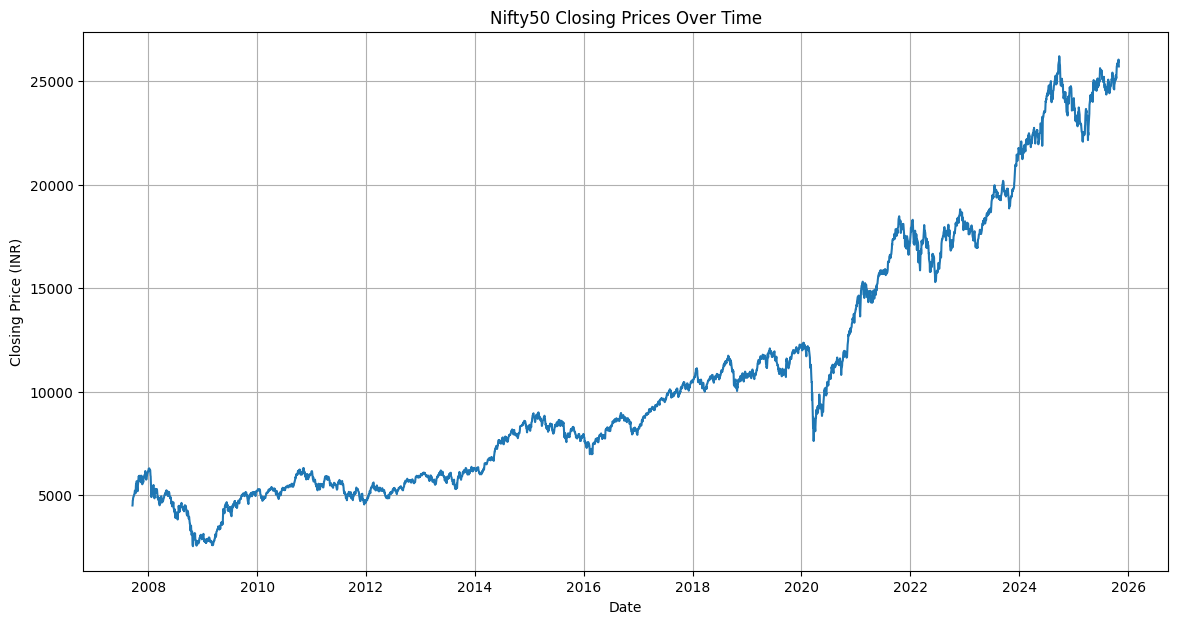

In [12]:
from matplotlib import pyplot as plt        
import seaborn as sns

plt.figure(figsize=(14, 7))
sns.lineplot(data=df, x=df['Date'], y='Close')
plt.title('Nifty50 Closing Prices Over Time')
plt.xlabel('Date')
plt.ylabel('Closing Price (INR)')
plt.grid(True)
plt.show()

